In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk

In [27]:
#Universal Constants
c=3*10**8
mu_0 = 4*(np.pi)*(10**-7)
epsilon = 8.854*10**-12
h_planck = 6.62607015*10**-34
hbar = (6.62607015*10**-34)/(2*np.pi)
k_b = 1.380649*10**-23
e = 1.60217663*10**-19

### Predicting the Resonant Frequencies $f_0$ for 1-4mm 
The resonant frequency of a CPW resonator of $\frac{\lambda}{4}$ can be found using the followng equation[1]:
$$
f_0 = \frac{c}{\sqrt{\epsilon_{eff}}}\frac{1}{4l}
$$
where $c$ is the speed of light, $\epsilon_{eff}$ is th effective permitivity of CPW and $l$ is length of the CPW with a factor of $4$ as it is a quarter wavelength resonator which implies $2l = \lambda_0$, the fundamental mode. This uses the lumped element approximations to derive.

To calculate the the effective permeability the following equation is used[2].
$$
\epsilon_{eff} = \frac{\epsilon_r + 1}{2} + \frac{\epsilon_r - 1}{2} \frac{1}{\sqrt{1+12d/W}}
$$  
where $d$ is the height of the substrate and $W$ is the width of microstrip. For a microstrip line built on top a single substrate. We will assume this method is vaild for CPW resonator.


In [28]:
def find_effective_permeability(e_r,d,W):
    '''
    Determines the effective dielectric constant of a
    CPW when there is a single substrate
    Input:
    -   e_r = Dieletric Constant of the substrate[float] 
    -   d   = Height of substrate[m,float]
    -   W   = Width of CPW[m,float]
    Output:
    -   e_e = Effective Dieletric Constant of CPW[float]
    '''
    e_e = ((e_r+1)/(2))+((e_r-1)/(2))*(1/(np.sqrt(1+(12*d/W))))
    return e_e

def find_resonator_frequency_lumped_approx(e_r,d,W,l):
    '''
    Finds the resonant frequency of a CPW resonator defined
    on a single substrate using the lumped element approximation
    for a quarter wavelength resonator
    Input:
    -   e_r = Dielectric constant of the subtrate[float]
    -   d   = Height of substrate[m,float]
    -   W   = Width of CPW[m,float]
    -   l   = Length of CPW resonator[m,float]
    Output:
    -   f0  = Resonant Frequency of CPW resonantor[Hz,float]
    '''
    e_e = find_effective_permeability(e_r,d,W)

    f0 = (c/(np.sqrt(e_e)))*(1/(4*l))
    return f0

theo_res_f = find_resonator_frequency_lumped_approx(11.6,270*(10**-6),10*(10**-6),12*(10**-3))
theo_res_f = theo_res_f/(10**9)
print(f'{theo_res_f} GHz')

2.433917419216113 GHz


In [29]:
#Resonator Lengths
l1 = 556.1*10**-6
l2 = 636.1*10**-6
l3 = 580.1*10**-6
l4 = 668.1*10**-6
l5 = 607.1*10**-6
l6 = 538.8*10**-6
l_vals = np.array([l1,l2,l3,l4,l5,l6])

#Substrate Height
h_s = 500*10**-6

#CPW width
w_CPW = 20*10**-6

#Cryo Sapphire dielectric constant
e_sap = 10.1

In [30]:
#Find Resoant Frequencies(GHz)
f0_lumped = (find_resonator_frequency_lumped_approx(e_sap,h_s,w_CPW,l_vals))/(10**9)
print(f0_lumped)

[55.94173605 48.90614592 53.62730463 46.5636872  51.2422985  57.73793508]


#### Conformal Mapping Techniques to find $f_0$
The phase velocity $v_p = c/\sqrt{\epsilon_eff}$ which is related to the resonant frequency $f_0$. 
$$
f_0 = \frac{v_p}{4l}
$$
$$
v_p = \frac{1}{\sqrt{L_lC_l}}
$$
Using conformal mapping techniques can be used to find the geometric contribution to $L_l$ and $C_l$.
$$
L_l = \frac{\mu_0}{4} \frac{K(k'_0)}{K(k_0)} \hspace{10mm} C_l = 4\epsilon_0\epsilon_{eff} \frac{K(k_0)}{K(k'_0)}
$$

Here, $K$ denotes the complete elliptic integral of the first kind with the arguments
$$
k_0 = \frac{w}{w+2s} \hspace{10mm} k'_0 = \sqrt{1-k^2_0}
$$


In [31]:
def find_f0_Conformal_Mapping(w,s,e_r,d,W,l):
    '''
    Determine the resonant frequencies for a 
    CPW resonator using conformal mapping techniques.
    Determines the Inductance (L_l) and Capacitance (C_l)
    per unit length. Uses calculations to determine 
    effective dielectric constant of the CPW. 
    Input:
    -   w   = centre conductor width[m,float]
    -   s   = seperation of centre conductor[m,float]
    -   e_r = dieletric constant of substrate[float]
    -   d   = height of substrate[m,float]
    -   W   = width of CPW[m,float]
    -   l   = length of CPW[m,float]
    Output:
    -   L_l = Magnetic Inductance of CPW per unit length[,float]
    -   C_L = Capcitance of CPW per unit length[F,float]
    -   f0  = Resonant Frequency of CPW[Hz,float]
    '''
    #Find Arguements of the First Kind
    k_0 = (w)/(w+2*s)
    k_prime = np.sqrt(1-k_0**2)

    #Find Effective Permeability
    e_eff = find_effective_permeability(e_r,d,W)

    #Elleptical Integrals
    L_l = ((mu_0)/(4))*(ellipk(k_prime**2))/(ellipk(k_0**2))
    C_l = 4*epsilon*e_eff*((ellipk(k_0**2))/(ellipk(k_prime**2)))

    #Find Resonant Frequencies
    f0 = ((1/np.sqrt(L_l*C_l))/(4*l))/(10**9)

    return L_l,C_l,f0


In [33]:
#Dimensions of CPW
central_width = 10*(10**-6)
seperation = 5*(10**-6)

#Apply Conformal Mapping
L_l_cm,C_l_cm,f0_CM = find_f0_Conformal_Mapping(central_width,seperation,e_sap,h_s,w_CPW,l_vals)

print('Resonant Frequencies using Conformal Mapping (GHz)')
print(f0_CM)
print('---------')
print('Resonant Frequencies using Lumped Approximation (GHz)')
print(f0_lumped)
print(C_l_cm*l_vals)

Resonant Frequencies using Conformal Mapping (GHz)
[55.90362811 48.87283068 53.5907733  46.53196766 51.20739185 57.69860355]
---------
Resonant Frequencies using Lumped Approximation (GHz)
[55.94173605 48.90614592 53.62730463 46.5636872  51.2422985  57.73793508]
[8.94824584e-14 1.02355317e-13 9.33443160e-14 1.07504460e-13
 9.76889058e-14 8.66987027e-14]


### Discussion
These values of the Resonant Frequencies are in agreement with each other as expected as both use the same value of the $\epsilon_{eff}$ to determine them and are in agreement in their values of $v_p$ the phase velocity. These values of the resonant frequency are valid assuming there is no contributions from kinetic inductance involved. Therefore an KeysightADS EM simulation of the circuit using PEC and the conductor and with no inputted is a valid method of verifying these theortical results.

### Introducing Kinetic Inductance
When a superconducting wire is suffciently thin, the kinetic inductance $L_K$ dominates over the magnetic inductance $L_m$ as calculated in conformal mapping. This occurs when the width $w$ and thickness $t$ of CPW resonantor $<<\lambda_L$ the london peneteration depth.
For the case of a homogenous superconducting cylinder of uniform circular or rectangular cross section. The kinetic inductance can be expressed as  
$$
L_K = \mu_0\lambda_L^2(T)\frac{l}{A}
$$  
which depends on the length of the $l$ of the wire, the area $A$, and the london penertation depth $\lambda_L$ which is a function of temperature. In this circuit design we will be using Niobium Nitride (NbN) at a thickness of 10nm. NbN $\lambda_L(0) = 230 \pm 20 \mathrm{nm}$ and $T_c = 14.8 \pm 0.3 K$. This is only vaid for $T$ near $T_C$, in 1D and for $I\approx0$. Therefore, with a wire of thickness $t=10 \mathrm{nm}$ and central conductor width $w=10 \mathrm{\mu m}$. The peneteration depth varies with temperature as follows:
$$
\lambda_L(T) = \frac{\lambda_L(0)}{\sqrt{1-\left(\frac{T}{T_c} \right)^4}}
$$

However, when working with thin films on the order of nm, the $\lambda_L$ varies therefore by considering Ginz-Landau theory of superconductivity, the normal state resistivity can be related to Kinetic inductance by[1]:
$$
L_{K,l} = \frac{0.18\hbar R_\square}{k_B T_c}\frac{1}{w}
$$
where the normal state resistance $R_N$ is defined as
$$
R_N = R_\square \frac{l}{w}
$$

where $R_\square$ is the normal state sheet resistance, $l$ is the wire length and $A$ is the cross sectional area. 

In [ ]:
def find_Kinetic_Inductance_london(l,t,w,T,Tc,lambda_L_0):
    '''
    Determines the Kinetic inductance of CPW resonator
    of a material identified by varying the charateristic
    qualities of Critical Temperature (Tc) and London
    Peneteration Depth at Zero Temperature (lambda_L_0)
    Input:
    -   l           = Length of CPW resonator[m,float]
    -   t           = Thickness of conductor[m,float]
    -   w           = Width of centre conductor[m,float]
    -   T           = Temperature of System[K,float]
    -   Tc          = Critical Temperature of Material [K,float]
    -   lambda_L_0  = London Peneteration depth of Material at 0K [K,float]
    Output:
    -   L_K         = Kinetic Inductance of CPW resonator[float]
    '''
    #Find London Penetration Depth
    lambda_L = (lambda_L_0)/(np.sqrt(1-(T/Tc)**4))

    #Calculate Kinetic Inductance
    L_K = mu_0*(lambda_L**2)*(l/(t*w))
    return L_K

def find_Kinetic_Inductance_Resistance(w,Tc,R_sq):
    '''
    Determines the Kinetic inductance per unit length
    for a CPW resonator a given thickness and width.
    Input:
    -   w       = central conductor width[m,float]
    -   Tc      = Critical Temperature of Thin Film[K,float]
    -   R_sq    = Normal State Sheet Resistance of conductor [ohms,float]
    Output:
    -   L_K_l   = Kinetic Inductance per unit length [H/m,float]

    '''
     #Calculate Kinetic Inductance per square
    L_K_sq = (hbar*R_sq)/(1.76*np.pi*k_b*Tc)
    
    #Per unit Length
    L_K_l = L_K_sq/w
    return L_K_l

In [35]:
# Parameters taken from James Potters Thesis for NbN
thickness = 10*10**-9
Temp = 10*10**-3
NbN_Tc = 9
NbN_lambda_L = 230*10**-9
NbN_R_sq= 1.075*10**3

# Computational Values of L_K
L_K_NbN_lon = find_Kinetic_Inductance_london(l_vals,thickness,central_width,Temp,NbN_Tc,NbN_lambda_L)
L_K_l_NbN_res = find_Kinetic_Inductance_Resistance(central_width,NbN_Tc,NbN_R_sq)

#print('Kinetic Inductance of NbN Nanowires using London Parameters')
#print(L_K_NbN_lon)
print('--------')
print('Kinetic Inductance of NbN Nanowires using Resistivity')
print(L_K_l_NbN_res*l_vals)
print('--------')
print('Magentic Inductance of NbN Nanowires')
print(L_l_cm*l_vals)

--------
Kinetic Inductance of NbN Nanowires using Resistivity
[9.17591090e-09 1.04959484e-08 9.57192216e-09 1.10239634e-08
 1.00174348e-08 8.89045278e-09]
--------
Magentic Inductance of NbN Nanowires
[2.23492072e-10 2.55643422e-10 2.33137477e-10 2.68503962e-10
 2.43988558e-10 2.16539342e-10]


In [ ]:
#Convert to per unit length
L_K_l_NbN_lon = L_K_NbN_lon/l_vals

#Resonant Frequencies
f0_kin_lon = (1/(4*l_vals*np.sqrt((L_l_cm+L_K_l_NbN_lon)*C_l_cm)))
f0_kin_res = (1/(4*l_vals*np.sqrt((L_l_cm+L_K_l_NbN_res)*C_l_cm)))

print('Resonant Frequencies using Conformal Mapping (GHz)')
print(f0_CM)
print('---------')
print('Resonant Frequencies using Lumped Approximation (GHz)')
print(f0_lumped)
print()
print()
print('Resonance Frequencies with L_K using London parameters (GHz)')
print(f0_kin_lon/(10**9))
print('------')
print('Resonance Frequencies with L_K using Resistivity (GHz)')
print(f0_kin_res/(10**9))


Resonant Frequencies using Conformal Mapping (GHz)
[55.90362811 48.87283068 53.5907733  46.53196766 51.20739185 57.69860355]
---------
Resonant Frequencies using Lumped Approximation (GHz)
[55.94173605 48.90614592 53.62730463 46.5636872  51.2422985  57.73793508]


Resonance Frequencies with L_K using London parameters (GHz)
[34.31492486 29.99926067 32.89524171 28.56238544 31.43226769 35.41672181]
------
Resonance Frequencies with L_K using Resistivity (GHz)
[8.62027103 7.53613067 8.26363165 7.17517246 7.89611714 8.89705404]


In [ ]:
#London Peneteration Depth using Normal Resistance Square
m_lambda_L = np.sqrt(((hbar*NbN_R_sq)/(1.76*np.pi*mu_0*k_b*NbN_Tc)*(thickness)))
print(m_lambda_L/10**-9)

1145.8907517518326


In [ ]:
print(f0_CM-(f0_kin_res/(10**9)))

[47.28335708 41.33670001 45.32714166 39.3567952  43.31127471 48.80154951]


### Discussion


In [ ]:
#Dimensions of Feedline
w_feed = 50*10**-6
s_feed = 30*10**-6
l_feed = (3600+1000+(np.pi*450.47*0.5 + np.pi*449.94*0.5))*10**-6
W_feed = 110*10**-6

L_l_Feed, C_L_Feed, f0_Feed= find_f0_Conformal_Mapping(w_feed,s_feed,e_sap,h_s,W_feed,l_feed)


In [ ]:
Z0_feed = np.sqrt(L_l_Feed/C_L_Feed)
print(Z0_feed)

51.168554055801046


In [ ]:
L_K_L_feed=find_Kinetic_Inductance_Resistance(w_feed,NbN_Tc,NbN_R_sq)
Z0_feed = np.sqrt((L_l_Feed+L_K_L_feed)/C_L_Feed)
print(Z0_feed)

151.70464749700682


### Finding Variation of $T_C$ and $R_\square$ with Thickness
To further refine values of we need to further consider the variation of the $T_C$ and $R_\square$ (normal state sheet resistance) with thickness $d (\mathrm{nm})$. This can be achieved by using the following equations[2]:
$$
T_C d = AR_\square^{-B}
$$
$$
\frac{T_c}{T_{c0}} = \mathrm{exp}(\gamma) \left (  \frac{1/\gamma -\sqrt{t/2} + t/4}{1/\gamma + \sqrt{t/2} +t/4} \right )^{1/\gamma}
$$
Here $ A=1.2 +1.3/-0.6 \times 10^5$ and $B = 1.04 \pm 0.12$ in Eq (1) and parameter $t$ defined as $t=\frac{R_\square}{4\pi R_Q}$. $R_Q$ is the resistance quantum for Cooper Pairs $R_Q = \frac{h}{4e^2} = 6.45 \mathrm{k\Omega}$.  In Eq(2), $T_{c0}$ is a fitted parameter identified as $T_{c0} = 13.4K$ and $\gamma$ is related to the elastic scattering time $\tau = 3.9 \mathrm{fs}$ by the relation:
$$
\tau = \frac{h}{k_B T_{c0}}e^{-\gamma}
$$

In [ ]:
Tc0 = 13.4
tau_elastic = 3.9*10**-15
A_measured = 1.2*10**5
B_measured = 1.04
R_Q = (h_planck)/(4*e**2)
gamma = np.log((h_planck)/(k_b*Tc0*tau_elastic))

alpha = (Tc0*(thickness*10**9)*np.exp(-gamma))/(A_measured)
beta = (4*np.pi*R_Q)**B_measured
print(gamma)
print(alpha)
print(beta)

6.822567324314002
1.2159625821800272e-06
127451.37391794682


In [ ]:
t_guess = 8.96819
R_sq = t_guess*(4*np.pi*R_Q)
T_c_guess = (A_measured*(R_sq**(-B_measured)))/(thickness*10**9)
print(R_sq)
print(T_c_guess)

727260.3614664195
0.009616648268078181


In [ ]:
rho_n_guess = R_sq*(thickness*central_width)
print(rho_n_guess)

7.272603614664194e-08


In [ ]:
#London Peneteration Depth using Normal Resistance Square
m_lambda_L_guess = np.sqrt(((hbar*R_sq)/(1.76*np.pi*mu_0*k_b*T_c_guess)*(thickness)))
print(m_lambda_L_guess/10**-9)

911786.8611510809


### Plotting Theortical and Simulated values for Resonant Frequencies

By plotting the the resonant frequency $f_0$ against $1/l$ where $l$ is the length of the resonator, the phase velocity can be extracted from the gradient of the curve. This can be achieved by the following relation:
$$
f_0 = \frac{v_p}{4}\times \frac{1}{l}
$$
The relation $v_p = 1/\sqrt{L_lC_l}$ can be used to derive $L_l$ from the gradient $m = v_p/4$. By assuming that measurements for $C_l$ made theoretically through conformal mapping are valid and accuracte, a simulated measurement of the inductance per unit length $L_l$ can be made. This value can be used to estimate the Kinetic Inductance at $10\mathrm{nm}$ which is vital in precisely adjusting the parameters in a simulation.
Therefore, the final relation between the gradient and Inductance per unit length $L_l$ is:
$$
L_l = \frac{1}{16m^2C_l}
$$



In [ ]:
# Input Data
sim_f0_kin_res = (np.array([5.566,4.680,4.645,4.434,4.162,6.206]))*10**9

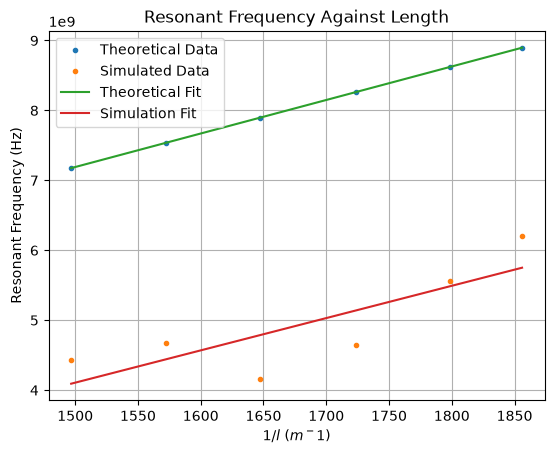

In [ ]:
#Polyfit
degree = 1

#
coeff_theory = np.polyfit(1/l_vals,f0_kin_res,degree)
coeff_sim = np.polyfit(1/l_vals,sim_f0_kin_res,degree)
xarr = np.linspace(min(1/l_vals),max(1/l_vals),1001)
fit_theory = np.poly1d(coeff_theory)
fit_sim = np.poly1d(coeff_sim)
yarr_theory = fit_theory(xarr)
yarr_sim = fit_sim(xarr)

plt.title('Resonant Frequency Against Length')
plt.xlabel(f'$1/l$ ($m^{-1}$)')
plt.ylabel(r'Resonant Frequency (Hz)')
plt.plot(1/l_vals,f0_kin_res,'.',label='Theoretical Data')
plt.plot(1/l_vals,sim_f0_kin_res,'.',label='Simulated Data')
plt.plot(xarr,yarr_theory,'-',label = 'Theoretical Fit')
plt.plot(xarr,yarr_sim,'-',label = 'Simulation Fit')
plt.grid()
plt.legend(loc='best')
plt.show()

In [ ]:
#Idenitfy Inductance Per Unit Length
L_l_theory = 1/(16*C_l_cm*(coeff_theory[0])**2)
L_l_sim =1/(16*C_l_cm*(coeff_sim[0])**2)

#Determine Impedance
Z0_sim = np.sqrt(L_l_sim/C_l_cm)

print('Theoretical Value for Inductance per Unit Length')
print(L_l_theory)
print('---------')
print('Simulated Value for Inductance per Unit Length')
print(L_l_sim)
print()
print()
print()
print('The Impedance for Simulated value:')
print(Z0_sim)


Theoretical Value for Inductance per Unit Length
1.6902361033838915e-05
---------
Simulated Value for Inductance per Unit Length
1.8215171618070918e-05



The Impedance for Simulated value:
336.452785095994


In [ ]:
L_K_sim = L_l_sim-L_l_cm
print(L_K_sim)
print(L_K_l_NbN_res)
m_lambda_L_sim = np.sqrt(L_K_sim*thickness*central_width/mu_0)
print(m_lambda_L_sim*10**9)

1.7813279742669862e-05
1.6500469158437917e-05
1190.6031084548354


# References
[1] J. A. Potter, "Experimental study of the quantum phase-slip effect in NbN nanowires," Ph.D. dissertation, Dept. Electron. Elect. Eng., University College London, London, U.K., 2021.~

[2] N. G. N. Constantino, M. S. Anwar, O. W. Kennedy, M. Dang, P. A. Warburton, and J. C. Fenton, "Emergence of quantum phase-slip behaviour in superconducting NbN nanowires: DC electrical transport and fabrication technologies," Nanomaterials, vol. 8, no. 6, art. no. 442, Jun. 2018, doi: 10.3390/nano8060442.